# 03 Tiny Transformer Training

This notebook trains a tiny Transformer for Arabic-to-English low-resource machine translation. It covers dataset loading, BPE vocabulary checks, CPU-safe DataLoaders, model definition, checkpointed training, resume behavior, BLEU evaluation, and final result displays.

## Imports and CPU Setup

This section imports the Python libraries used by the notebook, configures CPU threading for PyTorch, and records that notebook DataLoaders use `num_workers=0` to avoid Windows/Jupyter multiprocessing hangs.

In [1]:
# CPU optimization and imports.
# Note: OMP_NUM_THREADS and MKL_NUM_THREADS are most reliable when set before importing torch.
# If you change these values manually, restart the notebook kernel before rerunning heavy training cells.
import os
CPU_CORES = os.cpu_count() or 1
TORCH_THREADS = max(1, CPU_CORES - 1)
DATALOADER_WORKERS = 0

os.environ.setdefault("OMP_NUM_THREADS", str(TORCH_THREADS))
os.environ.setdefault("MKL_NUM_THREADS", str(TORCH_THREADS))

from pathlib import Path
import math
import random
import time
import json
import html
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu
import sentencepiece as spm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from IPython.display import display, Image, HTML

try:
    torch.set_num_threads(TORCH_THREADS)
except Exception as exc:
    print(f"Could not set torch num threads: {exc}")
try:
    torch.set_num_interop_threads(max(1, min(4, CPU_CORES // 2)))
except Exception as exc:
    print(f"Could not set torch interop threads, likely already initialized: {exc}")

print(f"CPU_CORES={CPU_CORES}")
print(f"TORCH_THREADS={torch.get_num_threads()}")
print(f"DATALOADER_WORKERS={DATALOADER_WORKERS}")

CPU_CORES=28
TORCH_THREADS=27
DATALOADER_WORKERS=0


## Configuration and Paths

This section defines training control flags, hyperparameters, dataset paths, output paths, and checkpoint paths. It also displays the active configuration as a table for reproducibility.

In [2]:
# Configuration.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
TOKENIZED_DIR = DATA_DIR / "tokenized"
VOCAB_DIR = DATA_DIR / "vocab"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TRANSLATIONS = PROJECT_ROOT / "outputs" / "translations"
OUTPUT_CHECKPOINTS = PROJECT_ROOT / "outputs" / "checkpoints"
for path in [OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_TRANSLATIONS, OUTPUT_CHECKPOINTS]:
    path.mkdir(parents=True, exist_ok=True)

RUN_TRAINING = True
AUTO_RESUME = True
FORCE_RESTART = False
SAVE_EVERY_EPOCH = True

CONFIG = {
    "seed": 42,
    "max_len": 80,
    "max_epochs": 40,
    "early_stopping_patience": 10,
    "batch_size": 32,
    "learning_rate": 3e-4,
    "weight_decay": 0.0,
    "label_smoothing": 0.0,
    "clip_grad_norm": 1.0,
    "d_model": 128,
    "nhead": 4,
    "num_encoder_layers": 2,
    "num_decoder_layers": 2,
    "dim_feedforward": 512,
    "dropout": 0.1,
    "eval_size": 1000,
    "device": "cpu",
    "train_src": TOKENIZED_DIR / "train.ar.bpe",
    "train_tgt": TOKENIZED_DIR / "train.en.bpe",
    "val_src": TOKENIZED_DIR / "validation.ar.bpe",
    "val_tgt": TOKENIZED_DIR / "validation.en.bpe",
    "test_src": TOKENIZED_DIR / "test.ar.bpe",
    "test_tgt": TOKENIZED_DIR / "test.en.bpe",
    "src_vocab": VOCAB_DIR / "sp_ar.vocab",
    "tgt_vocab": VOCAB_DIR / "sp_en.vocab",
    "src_spm": VOCAB_DIR / "sp_ar.model",
    "tgt_spm": VOCAB_DIR / "sp_en.model",
    "best_checkpoint": OUTPUT_CHECKPOINTS / "best_full_model.pt",
    "latest_checkpoint": OUTPUT_CHECKPOINTS / "latest_full_model.pt",
}
CONFIG_DISPLAY = {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()}
display(pd.DataFrame([CONFIG_DISPLAY]))

if not RUN_TRAINING:
    print("RUN_TRAINING=False: training cells will skip fitting and only display existing results.")

,seed,max_len,max_epochs,early_stopping_patience,batch_size,learning_rate,weight_decay,label_smoothing,clip_grad_norm,d_model,...,val_src,val_tgt,test_src,test_tgt,src_vocab,tgt_vocab,src_spm,tgt_spm,best_checkpoint,latest_checkpoint
0,42,80,40,10,32,0.0003,0.0,0.0,1.0,128,...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...,d:\Ahmed Sherif\Digilians\Deep Learning\Projec...


## Reproducibility and Tokenizers

This section sets the random seed, loads source and target BPE vocabularies, initializes SentencePiece processors, and verifies the special token IDs used by padding, BOS, EOS, and unknown tokens.

In [3]:
# Reproducibility helpers, vocabulary loading, and SentencePiece checks.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(CONFIG["seed"])

def read_lines(path):
    return Path(path).read_text(encoding="utf-8").splitlines()

def load_vocab(path):
    tokens = []
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if line.strip():
                tokens.append(line.rstrip("\n").split("\t", 1)[0])
    stoi = {token: idx for idx, token in enumerate(tokens)}
    itos = {idx: token for idx, token in enumerate(tokens)}
    return tokens, stoi, itos

def encode_pieces(pieces, stoi, add_bos=True, add_eos=True):
    ids = [stoi.get(piece, stoi["<unk>"]) for piece in pieces]
    if add_bos:
        ids.insert(0, stoi["<s>"])
    if add_eos:
        ids.append(stoi["</s>"])
    return ids

def decode_ids(ids, itos, pad_id, bos_id, eos_id):
    pieces = []
    for idx in ids:
        idx = int(idx)
        if idx == eos_id:
            break
        if idx in {pad_id, bos_id}:
            continue
        pieces.append(itos.get(idx, "<unk>"))
    return pieces

src_tokens, src_stoi, src_itos = load_vocab(CONFIG["src_vocab"])
tgt_tokens, tgt_stoi, tgt_itos = load_vocab(CONFIG["tgt_vocab"])
PAD_SRC, UNK_SRC, BOS_SRC, EOS_SRC = src_stoi["<pad>"], src_stoi["<unk>"], src_stoi["<s>"], src_stoi["</s>"]
PAD_TGT, UNK_TGT, BOS_TGT, EOS_TGT = tgt_stoi["<pad>"], tgt_stoi["<unk>"], tgt_stoi["<s>"], tgt_stoi["</s>"]

sp_ar = spm.SentencePieceProcessor(model_file=str(CONFIG["src_spm"]))
sp_en = spm.SentencePieceProcessor(model_file=str(CONFIG["tgt_spm"]))
sp_stats = pd.DataFrame([
    {"language": "Arabic", "pad_id": sp_ar.pad_id(), "unk_id": sp_ar.unk_id(), "bos_id": sp_ar.bos_id(), "eos_id": sp_ar.eos_id(), "piece_size": sp_ar.get_piece_size()},
    {"language": "English", "pad_id": sp_en.pad_id(), "unk_id": sp_en.unk_id(), "bos_id": sp_en.bos_id(), "eos_id": sp_en.eos_id(), "piece_size": sp_en.get_piece_size()},
])
if (sp_stats["pad_id"] < 0).any():
    raise ValueError("SentencePiece PAD token is missing; do not use UNK as PAD.")
display(sp_stats)
print({"src_vocab_size": len(src_tokens), "tgt_vocab_size": len(tgt_tokens)})

,language,pad_id,unk_id,bos_id,eos_id,piece_size
0,Arabic,0,1,2,3,8000
1,English,0,1,2,3,8000


{'src_vocab_size': 8000, 'tgt_vocab_size': 8000}


## Dataset and Collation

This section builds the translation dataset, applies `max_len` filtering, pads batches, and creates shifted decoder inputs and labels for autoregressive training.

In [4]:
# Dataset class and collate function.
class TranslationDataset(Dataset):
    def __init__(self, src_path, tgt_path, src_stoi, tgt_stoi, max_len=80):
        src_lines = read_lines(src_path)
        tgt_lines = read_lines(tgt_path)
        if len(src_lines) != len(tgt_lines):
            raise ValueError(f"Line mismatch: {src_path} has {len(src_lines)}, {tgt_path} has {len(tgt_lines)}")
        self.examples = []
        self.total = len(src_lines)
        self.filtered_long = 0
        for src_line, tgt_line in zip(src_lines, tgt_lines):
            src_pieces = src_line.split()
            tgt_pieces = tgt_line.split()
            if len(src_pieces) > max_len or len(tgt_pieces) > max_len:
                self.filtered_long += 1
                continue
            src_ids = encode_pieces(src_pieces, src_stoi, add_bos=True, add_eos=True)
            tgt_ids = encode_pieces(tgt_pieces, tgt_stoi, add_bos=True, add_eos=True)
            self.examples.append((src_ids, tgt_ids))
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        return self.examples[idx]

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_max = max(len(x) for x in src_batch)
    tgt_max = max(len(x) for x in tgt_batch)
    src = torch.full((len(batch), src_max), PAD_SRC, dtype=torch.long)
    tgt = torch.full((len(batch), tgt_max), PAD_TGT, dtype=torch.long)
    for row, ids in enumerate(src_batch):
        src[row, :len(ids)] = torch.tensor(ids, dtype=torch.long)
    for row, ids in enumerate(tgt_batch):
        tgt[row, :len(ids)] = torch.tensor(ids, dtype=torch.long)
    decoder_input = tgt[:, :-1]
    decoder_labels = tgt[:, 1:]
    return {"src": src, "tgt": tgt, "decoder_input": decoder_input, "decoder_labels": decoder_labels}

train_dataset = TranslationDataset(CONFIG["train_src"], CONFIG["train_tgt"], src_stoi, tgt_stoi, CONFIG["max_len"])
val_dataset = TranslationDataset(CONFIG["val_src"], CONFIG["val_tgt"], src_stoi, tgt_stoi, CONFIG["max_len"])
test_dataset = TranslationDataset(CONFIG["test_src"], CONFIG["test_tgt"], src_stoi, tgt_stoi, CONFIG["max_len"])

dataset_stats = pd.DataFrame([
    {"split": "train", "original": train_dataset.total, "kept": len(train_dataset), "removed": train_dataset.filtered_long},
    {"split": "validation", "original": val_dataset.total, "kept": len(val_dataset), "removed": val_dataset.filtered_long},
    {"split": "test", "original": test_dataset.total, "kept": len(test_dataset), "removed": test_dataset.filtered_long},
])
display(dataset_stats)

,split,original,kept,removed
0,train,50000,49441,559
1,validation,888,869,19
2,test,8567,8491,76


## DataLoaders

This section creates the train and validation DataLoaders. The notebook uses `num_workers=0` and `pin_memory=False` because CPU-only Windows/Jupyter training is more reliable without DataLoader multiprocessing.

In [5]:
# DataLoader creation.
# On Windows/Jupyter, DataLoader multiprocessing can hang, so the notebook uses num_workers=0.
# CPU acceleration is still handled by torch.set_num_threads.
def make_loader(dataset, batch_size, shuffle):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=False,
    )
    return loader, 0

train_loader, TRAIN_WORKERS_USED = make_loader(train_dataset, CONFIG["batch_size"], True)
val_loader, VAL_WORKERS_USED = make_loader(val_dataset, CONFIG["batch_size"], False)
print({"train_workers_used": TRAIN_WORKERS_USED, "val_workers_used": VAL_WORKERS_USED, "batch_size": CONFIG["batch_size"]})

{'train_workers_used': 0, 'val_workers_used': 0, 'batch_size': 32}


## Model Definition

This section defines sinusoidal positional encoding and the tiny encoder-decoder Transformer. It then creates the model and displays the total trainable parameter count.

In [6]:
# Model definition.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TinyTransformerMT(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size):
        super().__init__()
        self.d_model = CONFIG["d_model"]
        self.src_embedding = nn.Embedding(src_vocab_size, CONFIG["d_model"], padding_idx=PAD_SRC)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, CONFIG["d_model"], padding_idx=PAD_TGT)
        self.positional_encoding = PositionalEncoding(CONFIG["d_model"], CONFIG["dropout"], CONFIG["max_len"] + 2)
        self.transformer = nn.Transformer(
            d_model=CONFIG["d_model"],
            nhead=CONFIG["nhead"],
            num_encoder_layers=CONFIG["num_encoder_layers"],
            num_decoder_layers=CONFIG["num_decoder_layers"],
            dim_feedforward=CONFIG["dim_feedforward"],
            dropout=CONFIG["dropout"],
            batch_first=True,
        )
        self.output_projection = nn.Linear(CONFIG["d_model"], tgt_vocab_size)
    def forward(self, src, decoder_input):
        target_len = decoder_input.size(1)
        source_padding_mask = src.eq(PAD_SRC)
        target_padding_mask = decoder_input.eq(PAD_TGT)
        target_causal_mask = torch.triu(torch.ones(target_len, target_len, dtype=torch.bool, device=decoder_input.device), diagonal=1)
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(decoder_input) * math.sqrt(self.d_model))
        hidden = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=target_causal_mask,
            src_key_padding_mask=source_padding_mask,
            tgt_key_padding_mask=target_padding_mask,
            memory_key_padding_mask=source_padding_mask,
        )
        return self.output_projection(hidden)
    @torch.no_grad()
    def greedy_decode(self, src, max_len=80):
        self.eval()
        generated = torch.full((src.size(0), 1), BOS_TGT, dtype=torch.long, device=src.device)
        finished = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            logits = self(src, generated)
            next_token = logits[:, -1].argmax(dim=-1)
            next_token = next_token.masked_fill(finished, PAD_TGT)
            generated = torch.cat([generated, next_token.unsqueeze(1)], dim=1)
            finished |= next_token.eq(EOS_TGT)
            if finished.all():
                break
        return generated

model = TinyTransformerMT(len(src_tokens), len(tgt_tokens)).to(CONFIG["device"])
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
pd.DataFrame([{"total_parameters": total_params, "trainable_parameters": trainable_params}])

,total_parameters,trainable_parameters
0,4006208,4006208


## Training Setup

This section creates the loss function, optimizer, training log path, and batch progress interval shared by the following training helpers.

In [7]:
# Training objects and shared paths.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TGT, label_smoothing=CONFIG["label_smoothing"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
LOG_PATH = OUTPUT_TABLES / "full_training_log.csv"
PROGRESS_EVERY_N_BATCHES = 100


## Time and Display Helpers

These functions only format progress output and ETA for the notebook display. They do not affect model training, checkpointing, or evaluation.

In [8]:
# Time and display formatting helpers.
def format_duration(seconds):
    if seconds is None:
        return "estimating"
    seconds = max(0, int(float(seconds)))
    hours, rem = divmod(seconds, 3600)
    minutes, seconds = divmod(rem, 60)
    if hours:
        return f"{hours}h {minutes}m {seconds}s"
    return f"{minutes}m {seconds}s"

def format_finish_time(seconds_from_now):
    if seconds_from_now is None:
        return "estimating"
    finish_timestamp = time.time() + max(0, float(seconds_from_now))
    return time.strftime("%I:%M %p", time.localtime(finish_timestamp)).lstrip("0")

def average_epoch_time(history, fallback=None):
    epoch_times = []
    for row in history or []:
        try:
            epoch_time = float(row.get("epoch_time", 0.0))
        except (TypeError, ValueError):
            continue
        if epoch_time > 0:
            epoch_times.append(epoch_time)
    if epoch_times:
        return sum(epoch_times) / len(epoch_times)
    return fallback

def estimate_training_remaining(epoch, max_epochs, history, batch_idx=None, total_batches=None, epoch_elapsed=None):
    remaining_full_epochs = max(0, max_epochs - epoch)
    current_epoch_remaining = 0.0
    projected_epoch_time = None
    if batch_idx is not None and total_batches and epoch_elapsed is not None:
        epoch_fraction = min(1.0, max(0.0, batch_idx / max(1, total_batches)))
        if epoch_fraction > 0:
            projected_epoch_time = epoch_elapsed / epoch_fraction
            current_epoch_remaining = max(0.0, projected_epoch_time - epoch_elapsed)
    avg_epoch = average_epoch_time(history, fallback=projected_epoch_time)
    if avg_epoch is None:
        return None
    return current_epoch_remaining + remaining_full_epochs * avg_epoch

def render_epoch_status(epoch, max_epochs, remaining_seconds):
    return HTML(
        f"Epoch {epoch}/{max_epochs} | Remaining: {format_duration(remaining_seconds)} | "
        f"Finish: {format_finish_time(remaining_seconds)}"
    )

def render_batch_log(lines):
    text = "\n".join(html.escape(line) for line in lines)
    return HTML(
        "<div style='border:1px solid #ddd; height:250px; overflow-y:auto; padding:6px; "
        "background:#fff; font-family:Consolas, monospace; font-size:12px; white-space:pre-wrap;'>"
        f"{text or 'Starting...'}"
        "</div>"
    )


## Scrollable Batch Log Helpers

These functions manage the fixed-height scrollable batch log area used in the notebook so batch progress does not expand the page vertically.

In [9]:
# Scrollable batch log helpers.
def create_batch_log_output():
    state = {"lines": []}
    state["handle"] = display(render_batch_log(state["lines"]), display_id=True)
    return state

def clear_batch_log_output(batch_log_output):
    if batch_log_output is None:
        return
    batch_log_output["lines"].clear()
    batch_log_output["handle"].update(render_batch_log(batch_log_output["lines"]))

def append_batch_log_output(batch_log_output, line):
    if batch_log_output is None:
        print(line)
        return
    batch_log_output["lines"].append(line)
    batch_log_output["handle"].update(render_batch_log(batch_log_output["lines"]))


## Training History Helpers

These functions load old training logs, merge them with checkpoint history when resuming, and add readable duration columns for display.

In [10]:
# Training history helpers.
def add_display_time_columns(df):
    if df.empty:
        return df
    out = df.copy()
    if "epoch_time" in out.columns:
        out["epoch_time_display"] = out["epoch_time"].apply(format_duration)
    if "total_elapsed_time" in out.columns:
        out["total_elapsed_time_display"] = out["total_elapsed_time"].apply(format_duration)
    return out

def load_history_from_csv(path=LOG_PATH):
    if not Path(path).exists():
        return []
    df = pd.read_csv(path)
    return df.to_dict("records")

def merge_history(checkpoint_history, csv_history):
    by_epoch = {}
    for row in checkpoint_history or []:
        by_epoch[int(row["epoch"])] = row
    for row in csv_history or []:
        by_epoch[int(row["epoch"])] = row
    return [by_epoch[epoch] for epoch in sorted(by_epoch)]


## Training and Validation Functions

`train_one_epoch` performs one training epoch and writes simple batch progress lines. `validate` computes validation loss only after the epoch has completed.

In [11]:
# Training and validation functions.
def train_one_epoch(model, loader, epoch, max_epochs, history, status_handle=None, batch_log_output=None, progress_every=PROGRESS_EVERY_N_BATCHES):
    model.train()
    total_loss, total_tokens = 0.0, 0
    epoch_start = time.time()
    total_batches = len(loader)
    for batch_idx, batch in enumerate(loader, start=1):
        src = batch["src"].to(CONFIG["device"])
        decoder_input = batch["decoder_input"].to(CONFIG["device"])
        decoder_labels = batch["decoder_labels"].to(CONFIG["device"])
        logits = model(src, decoder_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), decoder_labels.reshape(-1))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["clip_grad_norm"])
        optimizer.step()
        tokens = decoder_labels.ne(PAD_TGT).sum().item()
        total_loss += loss.item() * tokens
        total_tokens += tokens
        if batch_idx % progress_every == 0 or batch_idx == total_batches:
            avg_train_loss = total_loss / max(1, total_tokens)
            epoch_elapsed = time.time() - epoch_start
            remaining = estimate_training_remaining(
                epoch, max_epochs, history,
                batch_idx=batch_idx,
                total_batches=total_batches,
                epoch_elapsed=epoch_elapsed,
            )
            if status_handle is not None:
                status_handle.update(render_epoch_status(epoch, max_epochs, remaining))
            line = f"batch {batch_idx}/{total_batches} loss={loss.item():.4f} avg_loss={avg_train_loss:.4f}"
            append_batch_log_output(batch_log_output, line)
    return total_loss / max(1, total_tokens)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        src = batch["src"].to(CONFIG["device"])
        decoder_input = batch["decoder_input"].to(CONFIG["device"])
        decoder_labels = batch["decoder_labels"].to(CONFIG["device"])
        logits = model(src, decoder_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), decoder_labels.reshape(-1))
        tokens = decoder_labels.ne(PAD_TGT).sum().item()
        total_loss += loss.item() * tokens
        total_tokens += tokens
    return total_loss / max(1, total_tokens)


## Checkpointing and Resume Helpers

These functions save per-epoch checkpoints, update the latest and best checkpoints, and restore training state when `AUTO_RESUME=True`. They also handle `FORCE_RESTART=True` without mixing old logs into a fresh run.

In [12]:
# Checkpointing and resume helpers.
def checkpoint_payload(epoch, train_loss, val_loss, best_val_loss, best_epoch, bad_epochs, history):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": None,
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": val_loss,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "bad_epochs": bad_epochs,
        "config": {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
        "seed": CONFIG["seed"],
        "history": history,
    }

def save_checkpoints(epoch, train_loss, val_loss, best_val_loss, best_epoch, bad_epochs, history, improved):
    payload = checkpoint_payload(epoch, train_loss, val_loss, best_val_loss, best_epoch, bad_epochs, history)
    epoch_path = OUTPUT_CHECKPOINTS / f"full_model_epoch_{epoch:03d}.pt"
    if SAVE_EVERY_EPOCH:
        torch.save(payload, epoch_path)
    torch.save(payload, CONFIG["latest_checkpoint"])
    if improved:
        torch.save(payload, CONFIG["best_checkpoint"])
    return epoch_path

def initialize_training_state(log_output=None):
    def log(message):
        append_batch_log_output(log_output, message)

    if not RUN_TRAINING:
        log("RUN_TRAINING=False: training is disabled. Existing results will be displayed only.")
        return None, None, None, None, load_history_from_csv(LOG_PATH)
    if FORCE_RESTART:
        log("FORCE_RESTART=True: ignoring existing checkpoints/logs and starting from epoch 1.")
        return 1, float("inf"), 0, 0, []
    if AUTO_RESUME and CONFIG["latest_checkpoint"].exists():
        csv_history = load_history_from_csv(LOG_PATH)
        checkpoint = torch.load(CONFIG["latest_checkpoint"], map_location=CONFIG["device"], weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        saved_epoch = int(checkpoint["epoch"])
        start_epoch = saved_epoch + 1
        best_val_loss = float(checkpoint["best_val_loss"])
        best_epoch = int(checkpoint.get("best_epoch", saved_epoch))
        bad_epochs = int(checkpoint.get("bad_epochs", 0))
        history = merge_history(checkpoint.get("history", []), csv_history)
        log(f"Resuming training from epoch {saved_epoch}")
        log(f"Loaded {len(csv_history)} previous epochs from existing log: {LOG_PATH}")
        log(f"Next epoch will be {start_epoch}")
        return start_epoch, best_val_loss, best_epoch, bad_epochs, history
    if AUTO_RESUME:
        log("AUTO_RESUME=True, but no latest checkpoint exists. Starting a fresh run from epoch 1.")
    else:
        log("AUTO_RESUME=False: starting a fresh run from epoch 1.")
    if LOG_PATH.exists():
        log(f"Existing log will be overwritten after epoch 1: {LOG_PATH}")
    return 1, float("inf"), 0, 0, []


## Log and Curve Saving

This function writes `outputs/tables/full_training_log.csv` and updates `outputs/figures/full_loss_curve.png` after each epoch.

In [13]:
# Log and curve saving.
def save_training_log_and_curve(history):
    df = pd.DataFrame(history)
    df.to_csv(LOG_PATH, index=False)
    if not df.empty:
        plt.figure(figsize=(8, 4.5))
        plt.plot(df["epoch"], df["train_loss"], marker="o", label="Train loss")
        plt.plot(df["epoch"], df["val_loss"], marker="o", label="Validation loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Full Tiny Transformer Training Curve")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_FIGURES / "full_loss_curve.png", dpi=200)
        plt.close()
    return df


## Main Training Cell

This cell initializes or resumes training state, runs the epoch loop, saves checkpoints and logs after every epoch, keeps the live epoch status separate from the scrollable batch log, and stops early when validation loss stops improving.

In [14]:
# Training cell.
# RUN_TRAINING controls whether fitting happens. AUTO_RESUME and FORCE_RESTART control startup behavior.

if not RUN_TRAINING:
    print("RUN_TRAINING=False: skipping training.")
    history = load_history_from_csv(LOG_PATH)
    start_epoch, best_val_loss, best_epoch, bad_epochs = None, None, None, None
else:
    epoch_status = display(HTML("Preparing training..."), display_id=True)
    batch_log_output = create_batch_log_output()
    start_epoch, best_val_loss, best_epoch, bad_epochs, history = initialize_training_state(log_output=batch_log_output)
    previous_elapsed = float(history[-1].get("total_elapsed_time", 0.0)) if history else 0.0
    completed_epoch = start_epoch - 1

    if start_epoch > CONFIG["max_epochs"]:
        append_batch_log_output(batch_log_output, "Training is already complete for the configured max_epochs.")
    else:
        for epoch in range(start_epoch, CONFIG["max_epochs"] + 1):
            epoch_start = time.time()
            append_batch_log_output(batch_log_output, "")
            append_batch_log_output(batch_log_output, f"Epoch {epoch}/{CONFIG['max_epochs']} started")
            append_batch_log_output(batch_log_output, "Waiting for first batch...")
            initial_remaining = estimate_training_remaining(epoch, CONFIG["max_epochs"], history)
            epoch_status.update(render_epoch_status(epoch, CONFIG["max_epochs"], initial_remaining))
            train_loss = train_one_epoch(
                model,
                train_loader,
                epoch,
                CONFIG["max_epochs"],
                history,
                status_handle=epoch_status,
                batch_log_output=batch_log_output,
            )
            val_loss = validate(model, val_loader)
            improved = val_loss < best_val_loss
            if improved:
                best_val_loss = val_loss
                best_epoch = epoch
                bad_epochs = 0
            else:
                bad_epochs += 1
            epoch_time = time.time() - epoch_start
            total_elapsed = previous_elapsed + epoch_time
            row = {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "best_val_loss": best_val_loss,
                "learning_rate": optimizer.param_groups[0]["lr"],
                "epoch_time": epoch_time,
                "total_elapsed_time": total_elapsed,
                "checkpoint_improved": improved,
            }
            history.append(row)
            remaining_training_time = estimate_training_remaining(epoch, CONFIG["max_epochs"], history)
            epoch_status.update(render_epoch_status(epoch, CONFIG["max_epochs"], remaining_training_time))
            previous_elapsed = total_elapsed
            checkpoint_path = save_checkpoints(epoch, train_loss, val_loss, best_val_loss, best_epoch, bad_epochs, history, improved)
            save_training_log_and_curve(history)
            completed_epoch = epoch
            append_batch_log_output(batch_log_output, "")
            append_batch_log_output(
                batch_log_output,
                f"Epoch {epoch} finished | "
                f"Train Loss={train_loss:.4f} | "
                f"Val Loss={val_loss:.4f} | "
                f"Best Val Loss={best_val_loss:.4f} | "
                f"Best Epoch={best_epoch} | "
                f"Epoch Time={format_duration(epoch_time)} | "
                f"Total Time={format_duration(total_elapsed)} | "
                f"ETA={format_duration(remaining_training_time)} | "
                f"Finish={format_finish_time(remaining_training_time)}"
            )
            append_batch_log_output(batch_log_output, "")
            if bad_epochs >= CONFIG["early_stopping_patience"]:
                append_batch_log_output(batch_log_output, "Early stopping triggered.")
                break

    save_training_log_and_curve(history)
    append_batch_log_output(batch_log_output, "Training cell finished.")

## Display Training Log

This section loads `full_training_log.csv`, adds readable time columns, and displays the complete training history after the training cell.

In [15]:
# Display full training log after the training cell.
if not LOG_PATH.exists():
    raise FileNotFoundError(f"No training log exists yet: {LOG_PATH}. Run training first or provide an existing full_training_log.csv.")
full_log = pd.read_csv(LOG_PATH)
full_log_display = add_display_time_columns(full_log)
print(f"Loaded full training log with {len(full_log_display)} epochs from {LOG_PATH}")
print("First five epochs:")
display(full_log_display.head())
print("Last five epochs:")
display(full_log_display.tail())
print("Complete training history table:")
display(full_log_display)

Loaded full training log with 40 epochs from d:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\outputs\tables\full_training_log.csv
First five epochs:


,epoch,train_loss,val_loss,best_val_loss,learning_rate,epoch_time,total_elapsed_time,checkpoint_improved,epoch_time_display,total_elapsed_time_display
0,1,5.684126,5.317301,5.317301,0.0003,440.086293,440.086293,True,7m 20s,7m 20s
1,2,5.108888,5.003189,5.003189,0.0003,448.468046,888.554339,True,7m 28s,14m 48s
2,3,4.875813,4.822261,4.822261,0.0003,470.192407,1358.746747,True,7m 50s,22m 38s
3,4,4.694864,4.700437,4.700437,0.0003,448.591493,1807.338240,True,7m 28s,30m 7s
4,5,4.553101,4.582872,4.582872,0.0003,453.287301,2260.625541,True,7m 33s,37m 40s


Last five epochs:


,epoch,train_loss,val_loss,best_val_loss,learning_rate,epoch_time,total_elapsed_time,checkpoint_improved,epoch_time_display,total_elapsed_time_display
35,36,3.472051,4.040343,4.036715,0.0003,456.747615,16719.297704,False,7m 36s,4h 38m 39s
36,37,3.458341,4.029450,4.029450,0.0003,463.409059,17182.706763,True,7m 43s,4h 46m 22s
37,38,3.444973,4.026723,4.026723,0.0003,457.693909,17640.400672,True,7m 37s,4h 54m 0s
38,39,3.431570,4.020097,4.020097,0.0003,459.875769,18100.276441,True,7m 39s,5h 1m 40s
39,40,3.420149,4.016555,4.016555,0.0003,458.118089,18558.394530,True,7m 38s,5h 9m 18s


Complete training history table:


,epoch,train_loss,val_loss,best_val_loss,learning_rate,epoch_time,total_elapsed_time,checkpoint_improved,epoch_time_display,total_elapsed_time_display
0,1,5.684126,5.317301,5.317301,0.0003,440.086293,440.086293,True,7m 20s,7m 20s
1,2,5.108888,5.003189,5.003189,0.0003,448.468046,888.554339,True,7m 28s,14m 48s
2,3,4.875813,4.822261,4.822261,0.0003,470.192407,1358.746747,True,7m 50s,22m 38s
3,4,4.694864,4.700437,4.700437,0.0003,448.591493,1807.338240,True,7m 28s,30m 7s
4,5,4.553101,4.582872,4.582872,0.0003,453.287301,2260.625541,True,7m 33s,37m 40s
5,6,4.416257,4.523479,4.523479,0.0003,455.747994,2716.373535,True,7m 35s,45m 16s
6,7,4.279558,4.478928,4.478928,0.0003,467.445916,3183.819450,True,7m 47s,53m 3s
7,8,4.165815,4.452670,4.452670,0.0003,470.389852,3654.209302,True,7m 50s,1h 0m 54s
8,9,4.215140,4.392923,4.392923,0.0003,461.900064,4116.109366,True,7m 41s,1h 8m 36s
9,10,4.178178,4.359271,4.359271,0.0003,468.782923,4584.892289,True,7m 48s,1h 16m 24s


## Display Loss Curve

This section displays the saved training/validation loss curve from `outputs/figures/full_loss_curve.png` if it exists.

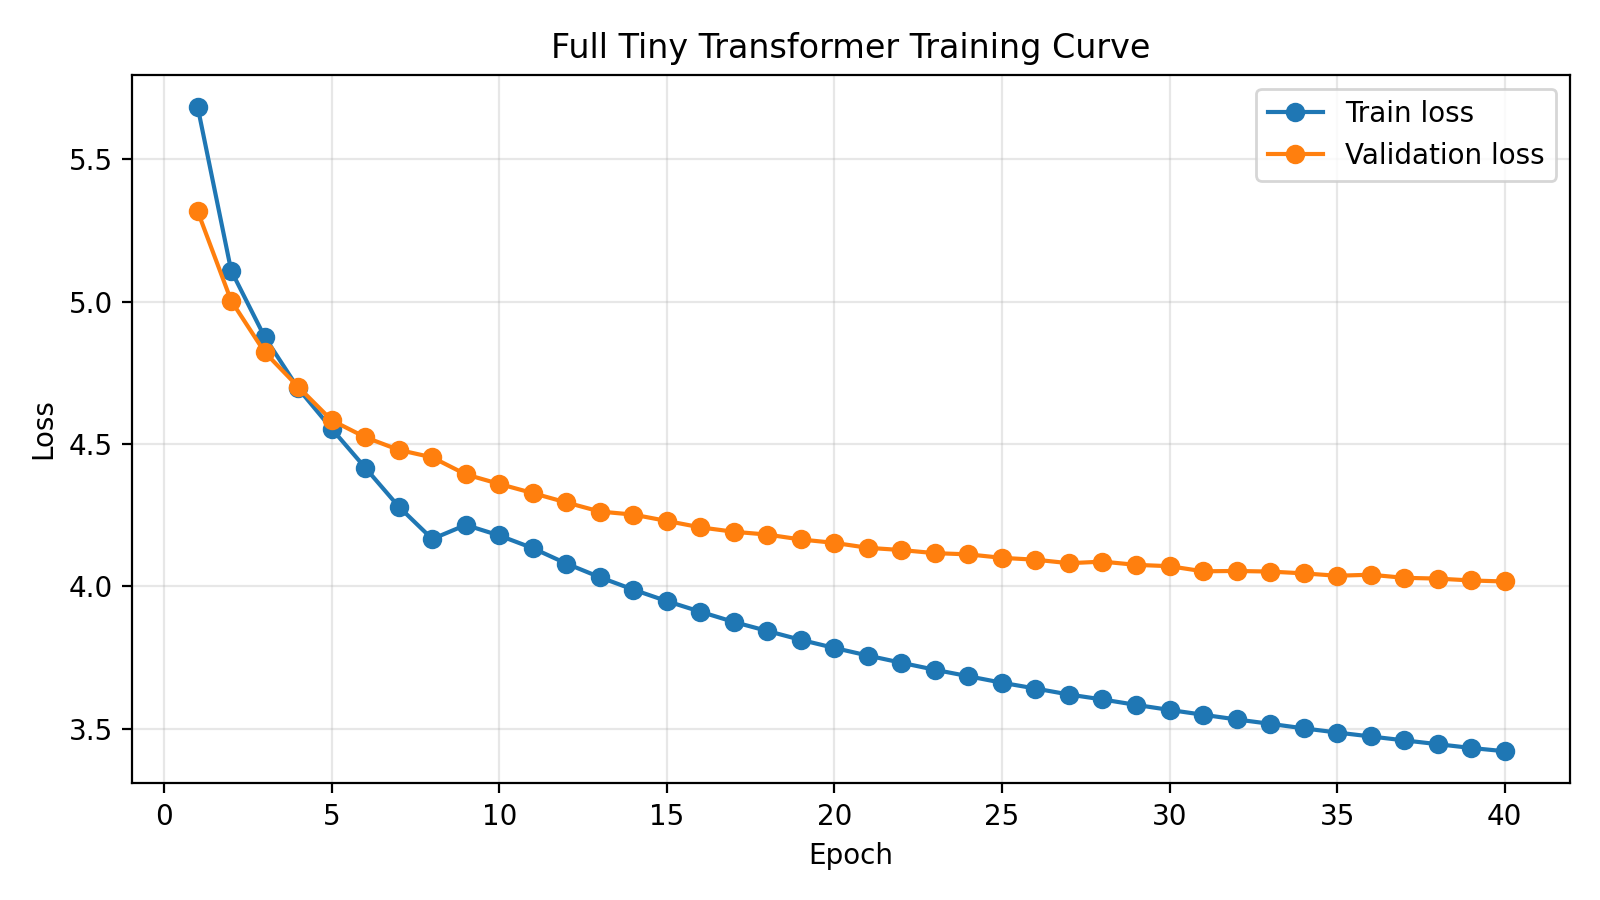

In [16]:
# Display full loss curve after the log has been loaded.
if not (OUTPUT_FIGURES / "full_loss_curve.png").exists():
    save_training_log_and_curve(full_log.to_dict("records"))
display(Image(filename=str(OUTPUT_FIGURES / "full_loss_curve.png")))

## BLEU and Detokenization Helpers

This section contains the detokenization helper used before BLEU scoring, so evaluation compares readable text rather than BPE pieces.

In [17]:
# BLEU and detokenization helpers.
def decode_bpe_lines(lines, processor):
    return [processor.decode(line.split()) for line in lines]


## Baseline Translation Helpers

This section builds and applies the position-based dictionary baseline used as a weak comparison system.

In [18]:
# Baseline translation helpers.
def build_position_dictionary(src_lines, tgt_lines):
    counts = defaultdict(Counter)
    for src_line, tgt_line in zip(src_lines, tgt_lines):
        src_tokens_line = src_line.split()
        tgt_tokens_line = tgt_line.split()
        if not src_tokens_line or not tgt_tokens_line:
            continue
        for src_index, src_token in enumerate(src_tokens_line):
            tgt_index = min(round(src_index * (len(tgt_tokens_line) - 1) / max(1, len(src_tokens_line) - 1)), len(tgt_tokens_line) - 1)
            counts[src_token][tgt_tokens_line[tgt_index]] += 1
    return {src_token: tgt_counts.most_common(1)[0][0] for src_token, tgt_counts in counts.items()}

def baseline_translate(line, dictionary):
    return " ".join(dictionary.get(token, "<unk>") for token in line.split())


## Transformer Greedy Prediction

This section generates Transformer translations from the best checkpoint using greedy decoding on the evaluation subset.

In [19]:
# Transformer greedy prediction.
@torch.no_grad()
def greedy_predict(dataset, limit):
    eval_examples = dataset.examples[:limit]
    eval_dataset = TranslationDataset(CONFIG["test_src"], CONFIG["test_tgt"], src_stoi, tgt_stoi, CONFIG["max_len"])
    eval_dataset.examples = eval_examples
    eval_loader = DataLoader(eval_dataset, batch_size=CONFIG["batch_size"], shuffle=False, collate_fn=collate_fn, num_workers=0)
    src_bpe, ref_bpe, hyp_bpe = [], [], []
    model.eval()
    for batch in eval_loader:
        src = batch["src"].to(CONFIG["device"])
        pred = model.greedy_decode(src, CONFIG["max_len"])
        for src_ids, pred_ids, ref_ids in zip(batch["src"].tolist(), pred.cpu().tolist(), batch["decoder_labels"].tolist()):
            src_bpe.append(" ".join(decode_ids(src_ids, src_itos, PAD_SRC, BOS_SRC, EOS_SRC)))
            hyp_bpe.append(" ".join(decode_ids(pred_ids, tgt_itos, PAD_TGT, BOS_TGT, EOS_TGT)))
            ref_bpe.append(" ".join(decode_ids(ref_ids, tgt_itos, PAD_TGT, BOS_TGT, EOS_TGT)))
    return src_bpe, ref_bpe, hyp_bpe


## Evaluation Execution and Saved Outputs

This section computes detokenized BLEU, saves Transformer and final comparison CSV files, writes prediction/sample translation files, and updates the BLEU comparison figure.

In [20]:
# Evaluation execution and saved outputs.
EVALUATION_AVAILABLE = False
transformer_bleu = None
baseline_bleu = None
transformer_results = pd.DataFrame()
final_results = pd.DataFrame()
samples = pd.DataFrame()

if not RUN_TRAINING:
    print("RUN_TRAINING=False: skipping slow greedy evaluation. Existing saved results can still be displayed from disk.")
elif not CONFIG["best_checkpoint"].exists():
    print("Best checkpoint not found. Train the model first.")
else:
    best_checkpoint = torch.load(CONFIG["best_checkpoint"], map_location=CONFIG["device"], weights_only=False)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}")

    eval_limit = min(CONFIG["eval_size"], len(test_dataset))
    src_bpe, ref_bpe, hyp_bpe = greedy_predict(test_dataset, eval_limit)
    src_text = decode_bpe_lines(src_bpe, sp_ar)
    ref_text = decode_bpe_lines(ref_bpe, sp_en)
    hyp_text = decode_bpe_lines(hyp_bpe, sp_en)
    transformer_bleu = sacrebleu.corpus_bleu(hyp_text, [ref_text])

    train_src_lines = read_lines(CONFIG["train_src"])
    train_tgt_lines = read_lines(CONFIG["train_tgt"])
    test_src_lines = read_lines(CONFIG["test_src"])[:eval_limit]
    test_tgt_lines = read_lines(CONFIG["test_tgt"])[:eval_limit]
    dictionary = build_position_dictionary(train_src_lines, train_tgt_lines)
    baseline_bpe = [baseline_translate(line, dictionary) for line in test_src_lines]
    baseline_text = decode_bpe_lines(baseline_bpe, sp_en)
    baseline_ref_text = decode_bpe_lines(test_tgt_lines, sp_en)
    baseline_src_text = decode_bpe_lines(test_src_lines, sp_ar)
    baseline_bleu = sacrebleu.corpus_bleu(baseline_text, [baseline_ref_text])

    transformer_results = pd.DataFrame([{
        "model": "tiny_transformer_full_greedy",
        "decoding": "greedy",
        "examples": len(hyp_text),
        "bleu": transformer_bleu.score,
        "bleu_summary": str(transformer_bleu),
    }])
    final_results = pd.DataFrame([
        {"model": "dictionary_position_baseline", "decoding": "position_dictionary", "examples": len(baseline_text), "bleu": baseline_bleu.score, "bleu_summary": str(baseline_bleu)},
        {"model": "tiny_transformer_full_greedy", "decoding": "greedy", "examples": len(hyp_text), "bleu": transformer_bleu.score, "bleu_summary": str(transformer_bleu)},
    ])

    predictions = pd.DataFrame({"arabic_input": src_text, "reference_english": ref_text, "transformer_output": hyp_text})
    sample_count = min(25, len(hyp_text), len(baseline_text))
    samples = pd.DataFrame({
        "arabic_input": baseline_src_text[:sample_count],
        "reference_english": baseline_ref_text[:sample_count],
        "baseline_output": baseline_text[:sample_count],
        "transformer_output": hyp_text[:sample_count],
    })

    transformer_results.to_csv(OUTPUT_TABLES / "transformer_results.csv", index=False)
    final_results.to_csv(OUTPUT_TABLES / "final_results.csv", index=False)
    predictions.to_csv(OUTPUT_TRANSLATIONS / "full_transformer_predictions.csv", index=False)
    samples.to_csv(OUTPUT_TRANSLATIONS / "full_transformer_samples.csv", index=False)
    samples.to_csv(OUTPUT_TRANSLATIONS / "sample_translations.csv", index=False)

    plt.figure(figsize=(7, 4))
    plt.bar(final_results["model"], final_results["bleu"])
    plt.ylabel("BLEU")
    plt.title("BLEU Comparison on Standardized Test Subset")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES / "bleu_comparison.png", dpi=200)
    plt.close()

    EVALUATION_AVAILABLE = True
    display(transformer_results)
    display(final_results)
    display(samples.head(10))


Loaded best checkpoint from epoch 40


d:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


,model,decoding,examples,bleu,bleu_summary
0,tiny_transformer_full_greedy,greedy,1000,6.239937,BLEU = 6.24 32.2/9.9/3.5/1.3 (BP = 1.000 ratio...


,model,decoding,examples,bleu,bleu_summary
0,dictionary_position_baseline,position_dictionary,1000,4.688637,BLEU = 4.69 39.8/8.5/2.2/0.6 (BP = 1.000 ratio...
1,tiny_transformer_full_greedy,greedy,1000,6.239937,BLEU = 6.24 32.2/9.9/3.5/1.3 (BP = 1.000 ratio...


,arabic_input,reference_english,baseline_output,transformer_output
0,قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان م...,"several years ago here at ted, peter skillman ...","before many years, here in ted,,, peter, form,...","the adoption of us have been here, a few years..."
1,والفكرة غاية في البساطة. فريق مكوّن من اربعة ي...,and the idea's pretty simple: teams of four ha...,"and the very in simplicity. a, a of four we to...","and one of the most famous bricker, one of the..."
2,يجب ان تكون المارش مالو علي القمة.,the marshmallow has to be on top.,"we to be the the, money, on the.",the top of the top of the top of the top.
3,ورغماً عن انها تبدو بسيطة للغاية، الا انها صعب...,"and, though it seems really simple, it's actua...","and the, about it look simple., the it difficu...","it's very simple, because it's very simple, ve..."
4,لذا فقد فكرت بان هذه فكرة مثيرة، وقمت بتضمينها...,"and so, i thought this was an interesting idea...","so we i that this idea interesting, and to,. i...",so i thought i was a creative idea that i was ...
5,وقد كان نجاحاً باهراً.,and it was a huge success.,"and was success, the,.",it was a success.
6,ومنذ ذلك الحين، قمت بعقد حوالي 70 ورشة عمل للت...,"and since then, i've conducted about 70 design...","and that,, i,, about 70 and,, to design throug...","and i did a lot of students, and i did this te..."
7,اذاً، في العادة، يبدا معظم الناس بتوجيه انفسهم...,"so, normally, most people begin by orienting t...","so, in,, it most people to add themselves this...","so most people start to get people, and they s..."
8,يتحدثون عنها، ويتعرفون علي كيف سيكون شكلها، وي...,"they talk about it, they figure out what it's ...","people about, and know on how it shape it, and...",and you know how they're going to be able to b...
9,ثم يقضون بعض الوقت في التخطيط، والتنظيم. انهم ...,"then they spend some time planning, organizing...","and it a some time in the planning, and, organ...","and then they're going to spend time, and then..."


## Final Summary

This section displays the final training summary, writes `full_training_summary.json`, and shows the BLEU comparison figure when evaluation has run.

,train_examples,validation_examples,epochs_completed,total_training_time,best_epoch,final_train_loss,best_validation_loss,final_validation_loss,transformer_bleu,baseline_bleu,transformer_beats_baseline,evaluation_available,cpu_cores,torch_threads,dataloader_workers_used
0,49441,869,40,5h 9m 18s,40,3.420149,4.016555,4.016555,6.239937,4.688637,True,True,28,27,0


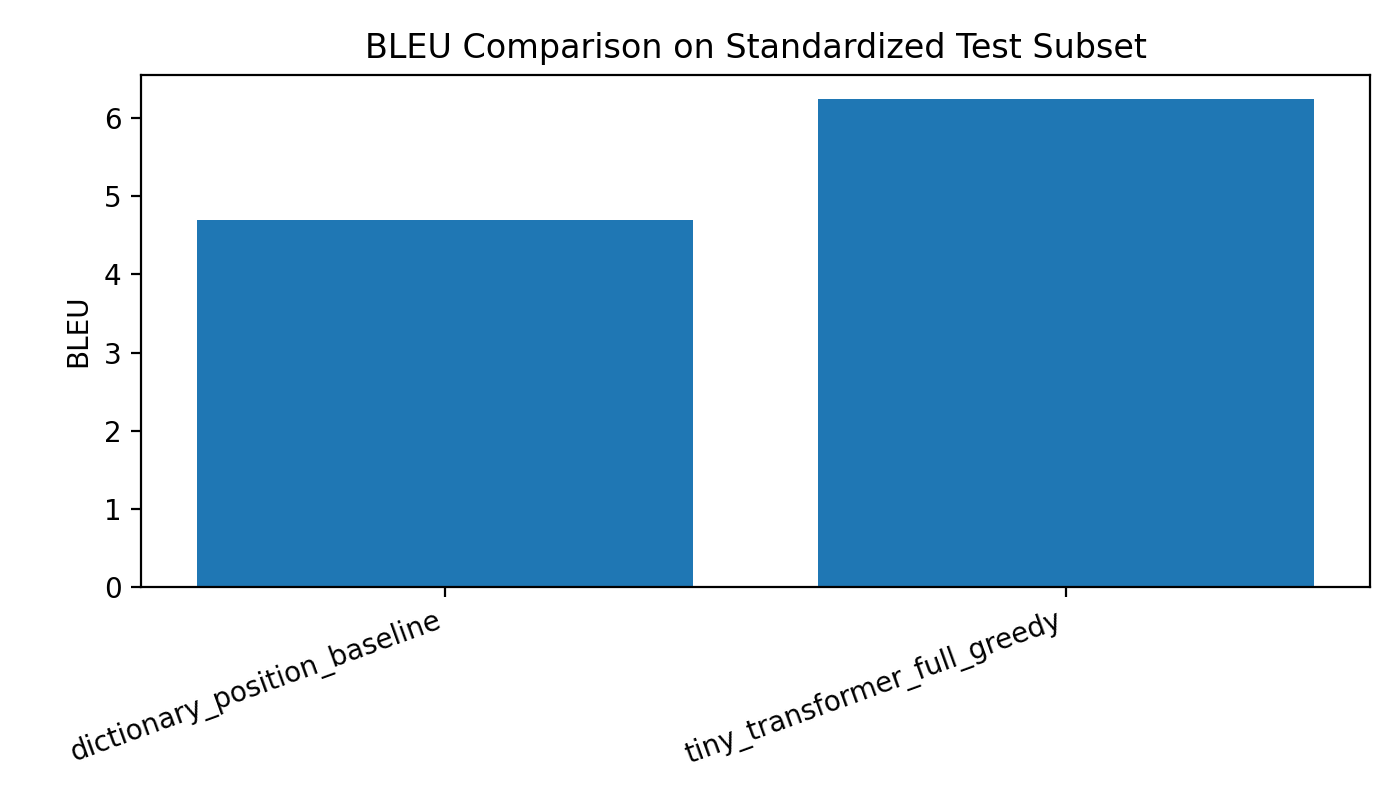

In [21]:
# Final summary and inline displays.
if not LOG_PATH.exists():
    raise FileNotFoundError(f"No training log exists yet: {LOG_PATH}. Run training first or provide an existing full_training_log.csv.")

full_log = pd.read_csv(LOG_PATH)
best_row = full_log.loc[full_log["val_loss"].idxmin()]
final_row = full_log.tail(1).iloc[0]
summary = {
    "train_examples": len(train_dataset),
    "validation_examples": len(val_dataset),
    "epochs_completed": int(final_row["epoch"]),
    "total_training_time": format_duration(float(final_row["total_elapsed_time"])),
    "best_epoch": int(best_row["epoch"]),
    "final_train_loss": float(final_row["train_loss"]),
    "best_validation_loss": float(best_row["val_loss"]),
    "final_validation_loss": float(final_row["val_loss"]),
    "transformer_bleu": float(transformer_bleu.score) if EVALUATION_AVAILABLE else None,
    "baseline_bleu": float(baseline_bleu.score) if EVALUATION_AVAILABLE else None,
    "transformer_beats_baseline": bool(transformer_bleu.score > baseline_bleu.score) if EVALUATION_AVAILABLE else None,
    "evaluation_available": EVALUATION_AVAILABLE,
    "cpu_cores": CPU_CORES,
    "torch_threads": torch.get_num_threads(),
    "dataloader_workers_used": TRAIN_WORKERS_USED,
}
(OUTPUT_TABLES / "full_training_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
summary_df = pd.DataFrame([summary])
display(summary_df)
if EVALUATION_AVAILABLE and (OUTPUT_FIGURES / "bleu_comparison.png").exists():
    display(Image(filename=str(OUTPUT_FIGURES / "bleu_comparison.png")))
else:
    print("BLEU comparison figure is unavailable because evaluation was skipped.")